In [1]:
import torch
from torch import nn
from torch import optim
from torch.autograd import grad
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.jit as jit

import numpy as np
import matplotlib.pyplot as plt

import os
import time
import pickle
import tqdm
import random
import typing
import itertools
from typing import Union
from datetime import datetime

# import LBFGS
# from LBFGS import FullBatchLBFGS

In [2]:
# Utility functions to be used elsewhere
def get_dt_string(now):
    return now.strftime("%d_%m_%Y-%H_%M_%S")
    
def set_seed(seed: int = 8888) -> None:

    """
    Function to set the PRNG seed of the sampling, NN initialization, etc.
    Used for reproducibility.

    Inputs: 
    - seed (int): PRNG seed. Default: 8888

    Outputs:
    None
    """

    if type(seed) != int:
        raise Exception("Input seed must be an integer.")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def np_to_tensor(arr: np.ndarray, reshape: bool = False, dims: tuple = (-1,1), device: torch.device = torch.device("cpu"), dtype: torch.dtype = torch.float32, requires_grad: bool = False) -> torch.Tensor:

    """
    Function to convert NumPy array to Pytorch tensor. Optionally, the tensor can be reshaped,
    which is specified with the boolean flag 'reshape'. If 'reshape' is True, the tensor is reshaped
    to have dimension 'dims', which should be passed as a tuple.

    Inputs:
    - arr (array): NumPy array to be converted to a PyTorch tensor.
    - reshape (bool): boolean flag indicating whether or not to reshape the array. Default: False
    - dims (tuple): tuple indicating what shape to reshape the array to, if desired. Default: (-1,1)
    - device (torch.device): indicates whether resulting tensor will be on CPU or GPU, and if GPU, which one. Default: torch.device("cpu")
    - dtype (torch.dtype): indicates what dtype the elements of the resulting tensor will have. Default: torch.float32
    - requires_grad (bool): boolean flag indicating whether or not operations on the resulting tensor will be recorded with autograd. Default: False

    Outputs:
    - PyTorch tensor corresponding to the input 'arr'.
    """

    if reshape:
        return torch.tensor(arr.reshape(dims), dtype=dtype, requires_grad=requires_grad, device=device)
    else:
        return torch.tensor(arr, dtype=dtype, requires_grad=requires_grad, device=device)


def tensor_to_np(tensor: torch.Tensor, reshape: bool = False, dims: tuple = (-1,1)) -> np.ndarray:

    """
    Function to convert PyTorch tensor to NumPy array. Optionally, the array can be reshaped,
    which is specified with the boolean flag 'reshape'. If 'reshape' is True, the array is reshaped
    to have dimension 'dims', which should be passed as a tuple.

    Inputs:
    - tensor (tensor): PyTorch tensor to be converted to a NumPy array.
    - reshape (bool): boolean flag indicating whether or not to reshape the array.
    - dims (tuple): tuple indicating what shape to reshape the array to, if desired.

    Outputs:
    - NumPy array corresponding to the input 'tensor'.
    """

    if reshape:
        return tensor.reshape(dims).detach().cpu().numpy()
    else:
        return tensor.detach().cpu().numpy()

def get_lr(optimizer) -> float:
    
    """
    Function gives the current (global) learning rate of the passed optimizer.

    Inputs:
    - optimizer (instance of torch.optim class)

    Outputs:
    - (Global) learning rate associated with 'optimizer'.
    """
    
    return optimizer.param_groups[0]['lr']

In [3]:
def derivative_t(f, dt):

    f_t = np.zeros_like(f)

    f_t[1:-1,:] = (0.5*f[2:,:] - 0.5*f[0:-2,:]) / dt             # 2nd order accurate central difference stencil for interior points
    f_t[0,:] = (-1.5*f[0,:] + 2.0*f[1,:] - 0.5*f[2,:]) / dt      # 2nd order accurate forward difference stencil for t_0 edge
    f_t[-1,:] = (0.5*f[-3,:] - 2.0*f[-2,:] + 1.5*f[-1,:]) / dt   # 2nd order accurate backward difference stencil for t_f edge

    return f_t

def derivative_x(f, dx):

    f_x = np.zeros_like(f)

    f_x[:,1:-1] = (0.5*f[:,2:] - 0.5*f[:,0:-2]) / dx             # 2nd order accurate central difference stencil for interior points
    f_x[:,0] = (-1.5*f[:,0] + 2.0*f[:,1] - 0.5*f[:,2]) / dx      # 2nd order accurate forward difference stencil for x_0 edge
    f_x[:,-1] = (0.5*f[:,-3] - 2.0*f[:,-2] + 1.5*f[:,-1]) / dx   # 2nd order accurate backward difference stencil for x_f edge

    return f_x

def derivative_xx(f, dx):

    f_xx = np.zeros_like(f)

    f_xx[:,1:-1] = (f[:,2:] - 2.0*f[:,1:-1] + f[:,0:-2]) / dx**2                  # 2nd order accurate central difference stencil (interior)
    f_xx[:,0] = (2.0*f[:,0] - 5.0*f[:,1] + 4.0*f[:,2] - 1.0*f[:,3]) / dx**2       # 2nd order accurate forward difference stencil (x_0 edge)
    f_xx[:,-1] = (2.0*f[:,-1] - 5.0*f[:,-2] + 4.0*f[:,-3] - 1.0*f[:,-4]) / dx**2  # 2nd order accurate backward difference stencil (x_f edge)

    return f_xx

def derivative_xt(f,dx,dt):
    f_xt = np.zeros_like(f)
    
    f_xt[:,1:-1] = (f[:,2:] - 2.0*f[:,1:-1] + f[:,0:-2]) / dx*dt                  # 2nd order accurate central difference stencil (interior)
    f_xt[:,0] = (2.0*f[:,0] - 5.0*f[:,1] + 4.0*f[:,2] - 1.0*f[:,3]) / dx*dt       # 2nd order accurate forward difference stencil (x_0 edge)
    f_xt[:,-1] = (2.0*f[:,-1] - 5.0*f[:,-2] + 4.0*f[:,-3] - 1.0*f[:,-4]) / dx*dt  # 2nd order accurate backward difference stencil (x_f edge)
 

In [4]:
def bohm_gross_dispersion(omega, vth):

    """
    
    Function to compute the wavenumber of an EPW in a warm plasma according to the Bohm-Gross dispersion relation.
    
    NOTE: this dispersion relation only applies when k * lambda_D << 1, i.e. the phase speed of the wave is large
    compared with the plasma thermal speed Vth. This function returns k * lambda_D as its second output, so it should be verified
    that this number is small compared to unity to ensure the dispersion relation holds.

    Inputs:
    - omega (float): frequency of EPW, in units of omega_pe.
    - vth (float): plasma thermal speed, in units of c.

    Outputs:
    - k (float): wavenumber computed according to Bohm-Gross dispersion, in units of omega_pe / c.
    - k_lambda_D (float): unitless product k * lambda_D, where k is obtained from the dispersion relation and lambda_D is the Debye length.
    
    """

    k = np.sqrt(omega**2 - 1) / (np.sqrt(3) * vth)
    k_lambda_D = k * vth

    return k, k_lambda_D

In [5]:
# Example k from arbitrary omega, vth:

omega_example = 1.01
vth_example = 0.05

k, k_lambda_D = bohm_gross_dispersion(omega_example, vth_example)
print(f"k = {k:.3f}, k*lambda_D = {k_lambda_D:.3f}")

k = 1.637, k*lambda_D = 0.082


In [6]:
def check_size_eq(lst):
    return not any(len(lst[0])!= len(i) for i in lst)
    
def phase_factor(delta):
    return np.exp(1j*delta)

def analytical_solution(x, t, omega, k, phi_amp, delta):

    phi_amp *= phase_factor(delta)

    phi = phi_amp * np.exp(1j * (k*x - omega*t))
    N = -1.0 * k**2 * phi_amp * np.exp(1j * (k*x - omega*t))
    V = -1.0 * k * omega * phi_amp * np.exp(1j * (k*x - omega*t))
    P = (1.0 - omega**2) * phi_amp * np.exp(1j * (k*x - omega*t))

    return phi, N, V, P

def generate_data(xmin, xmax, tmin, tmax, nx, nt, vth, omega_list, phi_amp_list, delta_list):

    if not check_size_eq([omega_list, phi_amp_list, delta_list]):
        raise Exception("Parameter lists are not the same size!")

    x = np.linspace(xmin, xmax, nx)
    t = np.linspace(tmin, tmax, nt)

    x_arr, t_arr = np.meshgrid(x,t)

    phi = np.zeros_like(x_arr, dtype=np.complex128)
    N = np.zeros_like(x_arr, dtype=np.complex128)
    V = np.zeros_like(x_arr, dtype=np.complex128)
    P = np.zeros_like(x_arr, dtype=np.complex128)

    for i in range(len(omega_list)):

        temp_phi, temp_N, temp_V, temp_P = analytical_solution(x_arr, t_arr, omega_list[i], \
                                                               bohm_gross_dispersion(omega_list[i], vth)[0], \
                                                               phi_amp_list[i], delta_list[i])
        phi += temp_phi
        N += temp_N
        V += temp_V
        P += temp_P

    return x_arr.flatten(), t_arr.flatten(), np.real(phi).flatten(), np.real(N).flatten(), np.real(V).flatten(), np.real(P).flatten()

def sparse_measurements(x, t, phi, num_samples):

    indices = np.random.choice(x.shape[0], num_samples, replace=False)

    return x[indices], t[indices], phi[indices]

def sparse_measurements2(x, t, phi, num_samples):

    indices = np.random.normal.choice(x.shape[0], num_samples, replace=False)

    return x[indices], t[indices], phi[indices]


def collocation_points(xmin, xmax, tmin, tmax, Nx, Nt, L, tau):

    x = np.linspace(xmin, xmax, Nx)
    t = np.linspace(tmin, tmax, Nt)

    x_coll, t_coll = np.meshgrid(x, t)

    dx = x[1] - x[0]
    dt = t[1] - t[0]

    return x_coll.flatten(), t_coll.flatten(), dx, dt

In [7]:
omega = 1.01   # wave frequency, in units of omega_pe
vth = 0.1      # electron thermal speed, in units of c
phi_amp = 1.0  # amplitude of electrostatic potential perturbation, in units of m_e c^2 / e
omega_list = [omega]
phi_amp_list = [phi_amp]
delta_list = [0.]

k, k_lambda_debye = bohm_gross_dispersion(omega_list[0], vth) # wavenumber obtained from B-G dispersion relation for EPWs in warm plasma 
                                                              # This is used to define the spatial extent of the generated data

T = (2*np.pi) / omega_list[0]          # period of wave, in units of 1 / omega_pe
lamda = (2*np.pi) / k                  # wavelength of wave, in units of c / omega_pe

xmin, xmax = 0, 3*lamda                # spatial extent of solution, in units of c / omega_pe
tmin, tmax = 0, 3*T                    # temporal extent of solution, in units of 1 / omega_pe

L = xmax - xmin    # spatial extent of generated data, in units of c / omega_pe
T = tmax - tmin    # temporal extent of generated data, in units of 1 / omega_pe
Nt = 2000          # number of time steps in generated data
Nx = 2000          # number of spatial points in generated data
Nt_coll = 200      # number of t points in collocation grid
Nx_coll = 200      # number of x points in collocation grid
dt = T / float(Nt) # time step of generated data
dx = L / float(Nx) # spatial resolution of generated data

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"k lambdaD = {k_lambda_debye:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_flat, T_flat, phi_flat, N_flat, V_flat, P_flat = generate_data(xmin, xmax, tmin, tmax, Nx, Nt, \
                                                                 vth, omega_list, phi_amp_list, delta_list)

x_sparse, t_sparse, phi_sparse = sparse_measurements(X_flat, T_flat, phi_flat, num_samples=1000)
x_coll, t_coll, dx_coll, dt_coll = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, T)

k = 8.1854e-01
k lambdaD = 8.1854e-02
L = 2.303e+01 [c / omega_pe]
T = 1.866e+01 [1 / omega_pe]
dx = 1.151e-02 [c / omega_pe]
dt = 9.331e-03 [1 / omega_pe]


In [8]:
phi_GT = phi_flat.reshape(Nt, Nx)
N_GT = N_flat.reshape(Nt, Nx)
V_GT = V_flat.reshape(Nt, Nx)
P_GT = P_flat.reshape(Nt, Nx)
P_x_GT = derivative_x(P_GT, dx)

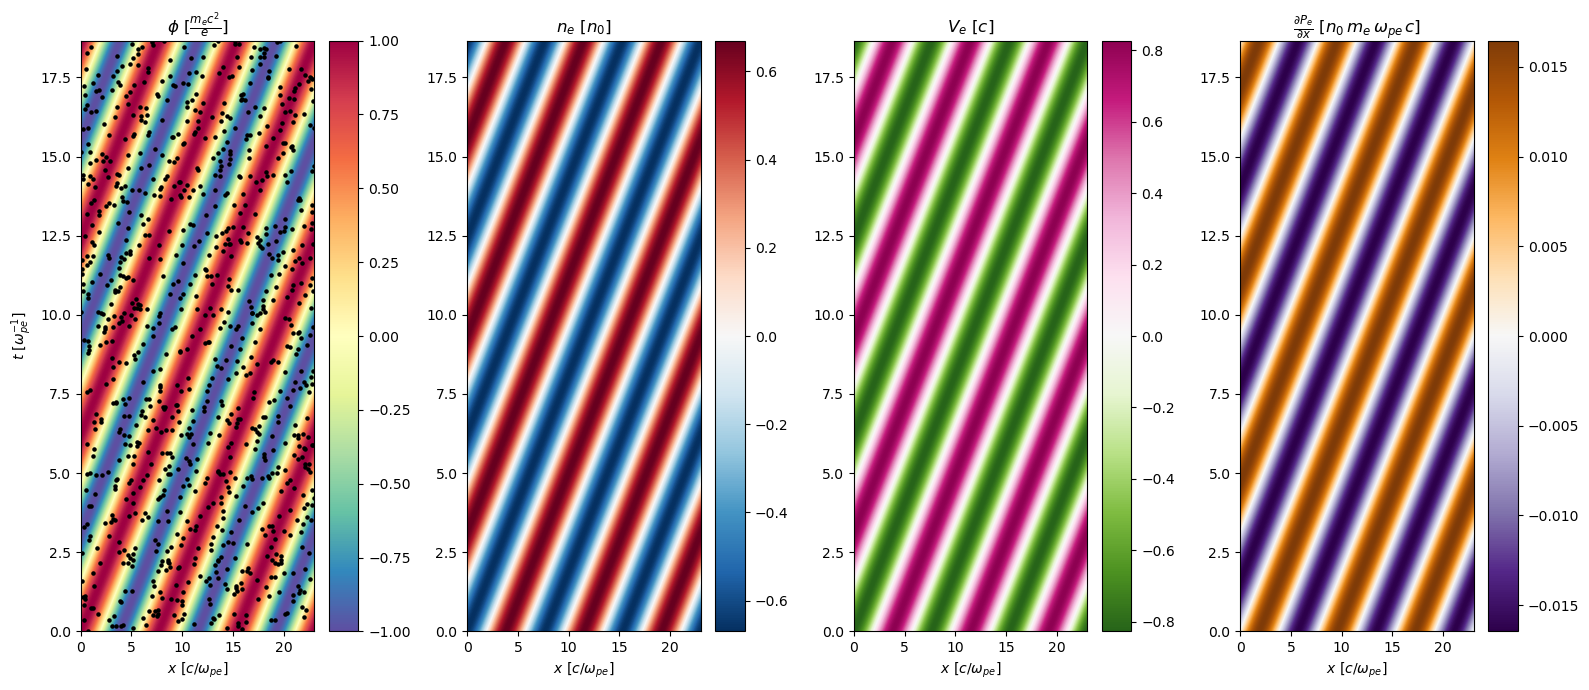

In [9]:
extent = [xmin, xmax, tmin, tmax]

plt.figure(figsize=(16,7))

plt.subplot(1, 4, 1)
plt.title(r'$\phi \, \, [\frac{m_e c^2}{e}]$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.ylabel(r'$t \, \, [\omega_{pe}^{-1}]$')
plt.imshow(phi_GT, extent=extent, origin='lower', aspect='auto', vmin=-np.max(np.abs(phi_GT)), vmax = np.max(np.abs(phi_GT)), cmap='Spectral_r')
plt.colorbar()
plt.scatter(x_sparse, t_sparse, s=5.0, c='k')

plt.subplot(1, 4, 2)
plt.title(r'$n_e \, \, [n_0]$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.imshow(N_GT, extent=extent, origin='lower', aspect='auto', vmin=-np.max(np.abs(N_GT)), vmax = np.max(np.abs(N_GT)), cmap='RdBu_r')
plt.colorbar()

plt.subplot(1, 4, 3)
plt.title(r'$V_e \, \, [c]$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.imshow(V_GT, extent=extent, origin='lower', aspect='auto', vmin=-np.max(np.abs(V_GT)), vmax = np.max(np.abs(V_GT)), cmap='PiYG_r')
plt.colorbar()

plt.subplot(1, 4, 4)
plt.title(r'$\frac{\partial P_e}{\partial x} \, \, [n_0 \, m_e \, \omega_{pe} \, c]$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.imshow(P_x_GT, extent=extent, origin='lower', aspect='auto', vmin=-np.max(np.abs(P_x_GT)), vmax = np.max(np.abs(P_x_GT)), cmap='PuOr_r')
plt.colorbar()

plt.tight_layout()
# plt.savefig('ground_truth_quantities.png', bbox_inches='tight')
plt.show()

In [10]:
N_t = derivative_t(N_GT, dt)
V_x = derivative_x(V_GT, dx)
V_t = derivative_t(V_GT, dt)
P_x = derivative_x(P_GT, dx)
phi_x = derivative_x(phi_GT, dx)
phi_xx = derivative_xx(phi_GT, dx)

phi_xt = derivative_t(phi_x,dt)

continuity = N_t + V_x
momentum = V_t - phi_x + P_x
poisson = phi_xx - N_GT
ampere = phi_xt + V_GT ##new addition (normalized units)

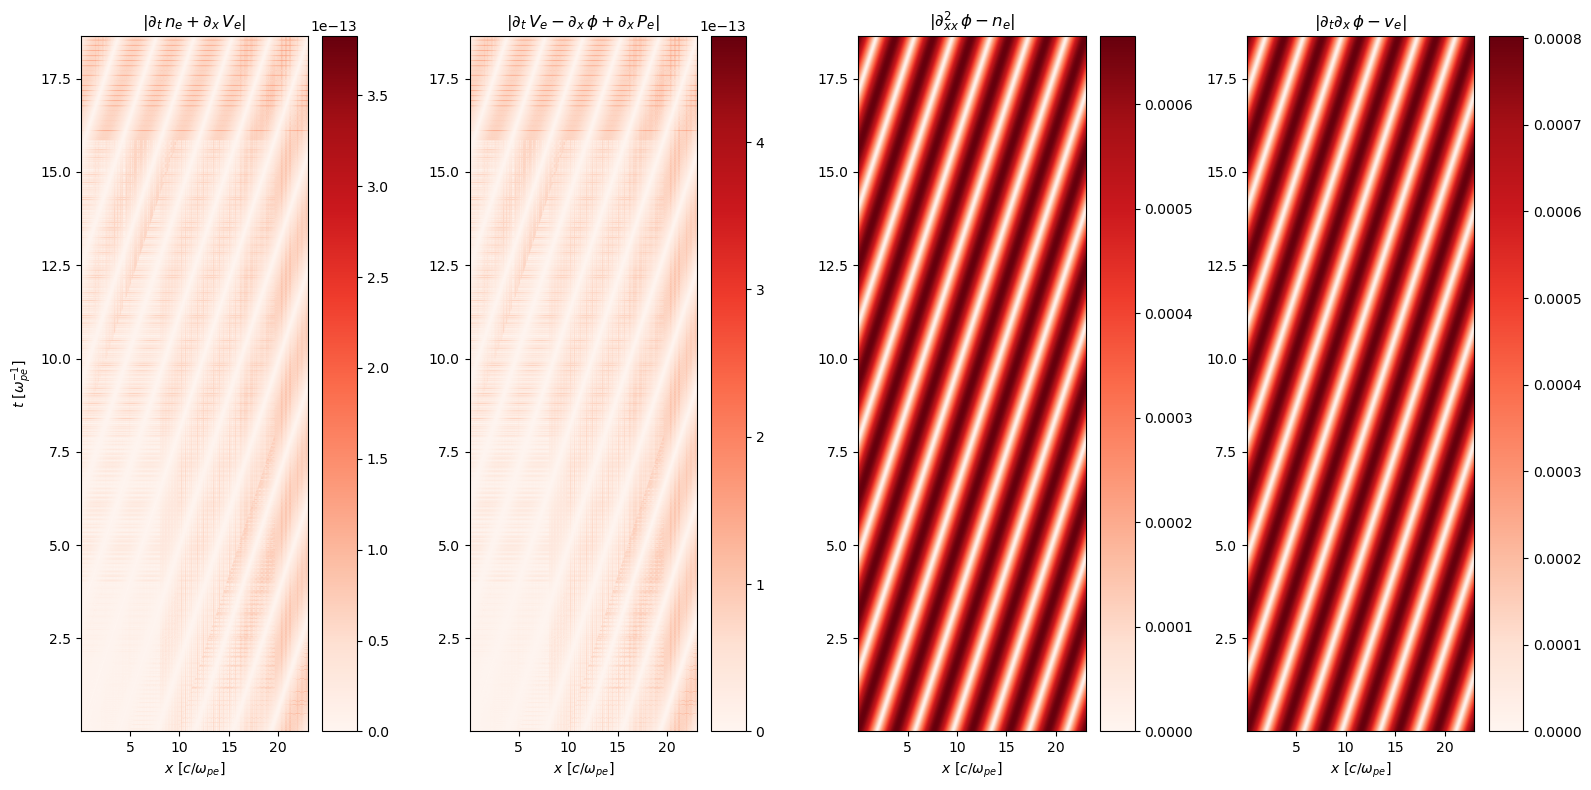

0.0008028141407473433


In [11]:
ext = [x_arr[1], x_arr[-2], t_arr[1], t_arr[-2]]

plt.figure(figsize=(16,8))

plt.subplot(1, 4, 1)
plt.title(r'$| \partial_t \, n_e + \partial_x \, V_e |$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.ylabel(r'$t \, \, [\omega_{pe}^{-1}]$')
plt.imshow(np.abs(continuity)[1:-1, 1:-1], extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
plt.colorbar()

plt.subplot(1, 4, 2)
plt.title(r'$| \partial_t \, V_e - \partial_x \, \phi + \partial_x \, P_e |$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.imshow(np.abs(momentum)[1:-1, 1:-1], extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
plt.colorbar()

plt.subplot(1, 4, 3)
plt.title(r'$| \partial^2_{xx} \, \phi - n_e |$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.imshow(np.abs(poisson)[1:-1, 1:-1], extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
plt.colorbar()

plt.subplot(1, 4, 4)
plt.title(r'$| \partial_{t}\partial_{x} \, \phi - v_e |$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.imshow(np.abs(ampere)[1:-1, 1:-1], extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
plt.colorbar()


plt.tight_layout()
plt.show()

print(np.max(np.abs(ampere)[1:-1, 1:-1]))

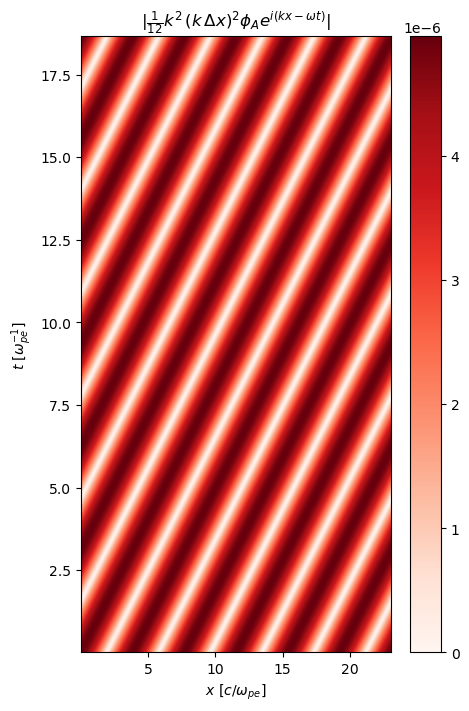

In [12]:
XX, TT = np.meshgrid(x_arr, t_arr)

plt.figure(figsize=(5,8))
plt.title(r'$|\frac{1}{12} k^2 \, (k \, \Delta x)^2 \phi_A e^{i(k x - \omega t)}|$')
plt.ylabel(r'$t \, \, [\omega_{pe}^{-1}]$')
plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
plt.imshow(np.abs(np.real((1/12)*k**4*dx**2*phi_amp*np.exp(1j*(k*XX - omega*TT)))), extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
plt.colorbar()

In [13]:
continuity_smallness_indicator = np.zeros(Nt)
momentum_smallness_indicator = np.zeros(Nt)
poisson_smallness_indicator = np.zeros(Nt)
ampere_smallness_indicator = np.zeros(Nt)


for i in range(Nt):
    
    continuity_snapshot = np.abs(continuity)[i,:]
    continuity_snapshot_norm = np.max(np.array([np.std(N_t[i,:]), np.std(V_x[i,:])]))
    continuity_snapshot_normalized = continuity_snapshot / (np.ones_like(continuity_snapshot)*continuity_snapshot_norm)
    continuity_smallness_indicator[i] = np.mean(continuity_snapshot_normalized)

    momentum_snapshot = np.abs(momentum)[i,:]
    momentum_snapshot_norm = np.max(np.array([np.std(V_t[i,:]), np.std(phi_x[i,:]), np.std(P_x_GT[i,:])]))
    momentum_snapshot_normalized = momentum_snapshot / (np.ones_like(momentum_snapshot)*momentum_snapshot_norm)
    momentum_smallness_indicator[i] = np.mean(momentum_snapshot_normalized)

    poisson_snapshot = np.abs(poisson)[i,:]
    poisson_snapshot_norm = np.max(np.array([np.std(phi_xx[i,:]), np.std(N_GT[i,:])]))
    poisson_snapshot_normalized = poisson_snapshot / (np.ones_like(poisson_snapshot)*poisson_snapshot_norm)
    poisson_smallness_indicator[i] = np.mean(poisson_snapshot_normalized)
    
    ampere_snapshot = np.abs(ampere)[i,:]
    ampere_snapshot_norm = np.max(np.array([np.std(phi_xt[i,:]), np.std(V_GT[i,:])]))
    ampere_snapshot_normalized = ampere_snapshot / (np.ones_like(ampere_snapshot)*ampere_snapshot_norm)
    ampere_smallness_indicator[i] = np.mean(ampere_snapshot_normalized)
    

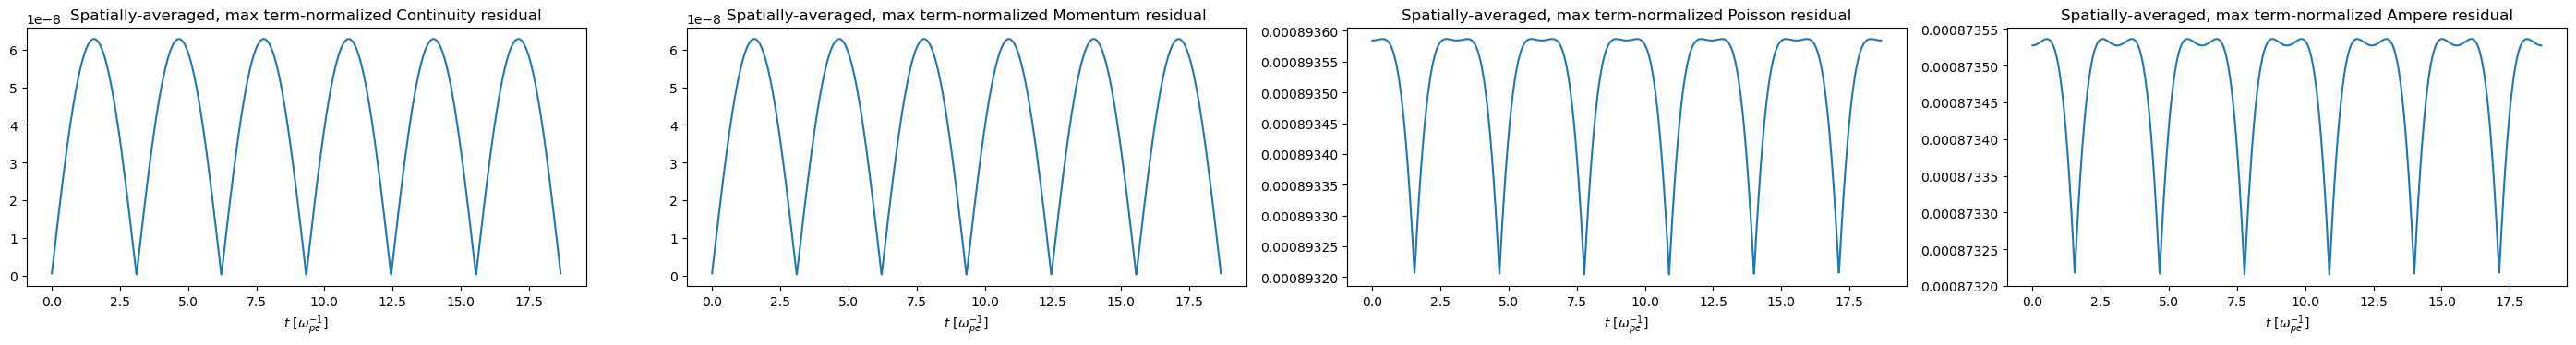

In [14]:
plt.figure(figsize=(28,4))

plt.subplot(1, 4, 1)
plt.title('Spatially-averaged, max term-normalized Continuity residual')
plt.xlabel(r'$t \, \, [\omega_{pe}^{-1}]$')
plt.plot(t_arr[1:-1], continuity_smallness_indicator[1:-1])

plt.subplot(1, 4, 2)
plt.title('Spatially-averaged, max term-normalized Momentum residual')
plt.xlabel(r'$t \, \, [\omega_{pe}^{-1}]$')
plt.plot(t_arr[1:-1], momentum_smallness_indicator[1:-1])

plt.subplot(1, 4, 3)
plt.title('Spatially-averaged, max term-normalized Poisson residual')
plt.xlabel(r'$t \, \, [\omega_{pe}^{-1}]$')
plt.plot(t_arr[1:-1], poisson_smallness_indicator[1:-1])

plt.subplot(1, 4, 4)
plt.title('Spatially-averaged, max term-normalized Ampere residual')
plt.xlabel(r'$t \, \, [\omega_{pe}^{-1}]$')
plt.plot(t_arr[1:-1], ampere_smallness_indicator[1:-1])


plt.tight_layout()
plt.show()

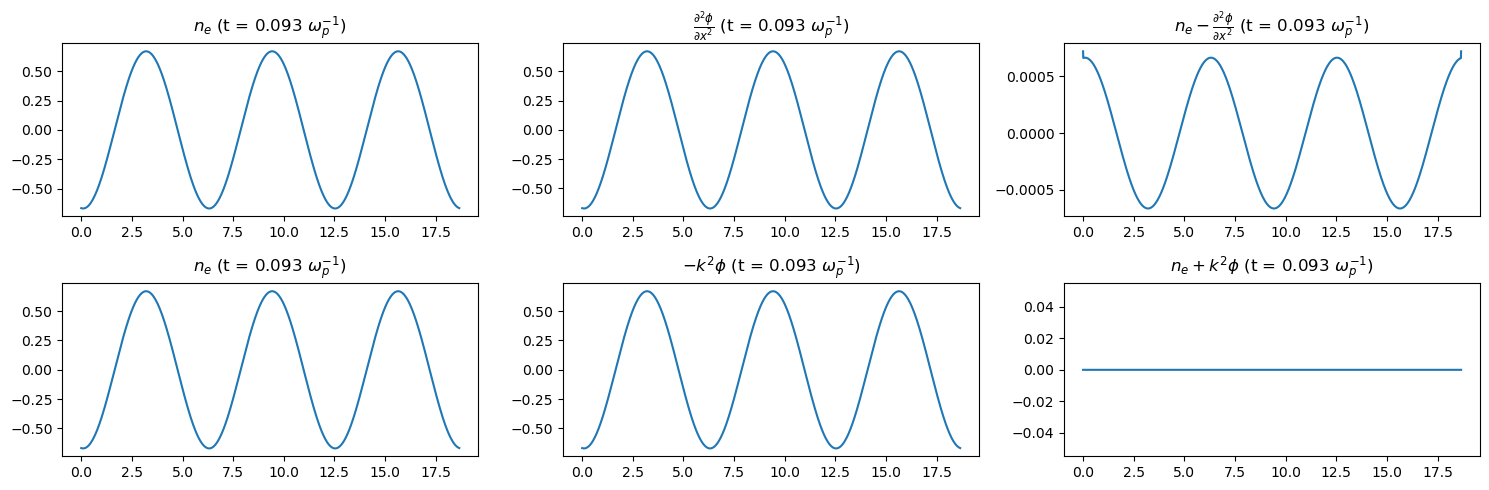



Is poisson Law being obeyed using finite-differencing w/ 2nd derivatives on phi? False
Is poisson Law being obeyed using the analytical expression for d^2(phi) / dx^2? True


In [15]:
i_t = 10

plt.figure(figsize=(15,5))

plt.subplot(2,3,1)
plt.plot(t_arr, N_GT[i_t,:])
plt.title(r'$n_e$' + f" (t = {t_arr[i_t]:.3f}" + r'$ \, \, \omega_p^{-1} $)')

plt.subplot(2,3,2)
plt.plot(t_arr, phi_xx[i_t,:])
plt.title(r'$\frac{\partial^2 \phi}{\partial x^2}$' + f" (t = {t_arr[i_t]:.3f}" + r'$ \, \, \omega_p^{-1} $)')

diff1 = N_GT[i_t,:] - phi_xx[i_t,:]
plt.subplot(2,3,3)
plt.plot(t_arr, diff1)
plt.title(r'$n_e - \frac{\partial^2 \phi}{\partial x^2}$' + f" (t = {t_arr[i_t]:.3f}" + r'$ \, \, \omega_p^{-1} $)')

plt.subplot(2,3,4)
plt.plot(t_arr, N_GT[i_t,:])
plt.title(r'$n_e$' + f" (t = {t_arr[i_t]:.3f}" + r'$ \, \, \omega_p^{-1} $)')

plt.subplot(2,3,5)
plt.plot(t_arr, -k**2*phi_GT[i_t,:])
plt.title(r'$-k^2 \phi$' + f" (t = {t_arr[i_t]:.3f}" + r'$ \, \, \omega_p^{-1} $)')

diff2 = (N_GT[i_t,:] + k**2*phi_GT[i_t,:])
plt.subplot(2,3,6)
plt.plot(t_arr, diff2)
plt.title(r'$n_e + k^2 \phi$' + f" (t = {t_arr[i_t]:.3f}" + r'$ \, \, \omega_p^{-1} $)')

plt.tight_layout()
plt.show()

print('\n')
print('Is poisson Law being obeyed using finite-differencing w/ 2nd derivatives on phi?' , all(np.isclose(np.zeros_like(diff1), diff1)))
print('Is poisson Law being obeyed using the analytical expression for d^2(phi) / dx^2?', all(np.isclose(np.zeros_like(diff2), diff2)))

In [16]:
# Helper functions for initialization of network parameters

def xavier_init_weights(network: nn.Module) -> nn.Module:
    with torch.no_grad():
        print("Initializing NN with glorot initialization...\n")
        for m in network:
            if hasattr(m, 'weight'):
                nn.init.xavier_normal_(m.weight)
                m.bias.data.fill_(0.0)

    return network

def kaiming_init_weights(network: nn.Module) -> nn.Module:
    with torch.no_grad():
        print("Initializing NN with he initialization...\n")
        for m in network:
            if hasattr(m, 'weight'):
                nn.init.kaiming_normal_(m.weight)
                m.bias.data.fill_(0.0)

    return network

# Helper function for initialization of activation function

def init_param(w0: float, device: torch.device, adaptive: bool) -> nn.Parameter:
    return nn.Parameter(torch.tensor(w0, dtype=torch.float32, requires_grad=adaptive, device=device))

# Helper function for Fourier Feature embedding

def encode_input(inp: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    input_proj = (2.0*torch.pi*inp) @ B.t()
    return torch.cat([torch.sin(input_proj), torch.cos(input_proj)], dim=-1)

# Activation function definitions

class Sin(nn.Module):

    def __init__(self, device: torch.device, w0: float = 1., adaptive: bool = False) -> None:
        super(Sin, self).__init__()
        self.w0 = init_param(w0, device, adaptive)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.w0 * x)

class Tanh(nn.Module):

    def __init__(self, device: torch.device, w0: float = 1., adaptive: bool = False) -> None:
        super(Tanh, self).__init__()
        self.w0 = init_param(w0, device, adaptive)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.tanh(self.w0 * x)

class Swish(nn.Module):

    def __init__(self, device: torch.device, w0: float = 1., adaptive: bool = False) -> None: 
        super(Swish, self).__init__()
        self.w0 = init_param(w0, device, adaptive)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.sigmoid(self.w0 * x)

########################################################################################################################################

# Main FC-NN class

class MLP(nn.Module):

    def __init__(self, extent: np.ndarray, device: torch.device, num_hidden_layers: int = 3, hidden_size: int = 50, activation: str = 'tanh', adaptive_af: bool = False, init: Union[None, str] = None, input_encoding: bool = False, sigma: float = 1.0, single_output: bool = False) -> None:

        super(MLP, self).__init__()

        # extent should be array[tmin, tmax, xmin, xmax]

        self.tmin = torch.tensor(extent[0], dtype=torch.float32, device=device, requires_grad=False)
        self.tmax = torch.tensor(extent[1], dtype=torch.float32, device=device, requires_grad=False)
        self.xmin = torch.tensor(extent[2], dtype=torch.float32, device=device, requires_grad=False)
        self.xmax = torch.tensor(extent[3], dtype=torch.float32, device=device, requires_grad=False)

        self.num_hidden_layers = num_hidden_layers
        self.hidden_size = hidden_size
        self.input_size = 2
        self.elapsed_iterations = 0

        if single_output:
            self.output_size = 1
        else:
            self.output_size = 4 # phi, N, V, P_x
            
        if activation == 'tanh' or activation == 'Tanh':
            self.activation_fn = Tanh(device, adaptive=adaptive_af)
            
        elif activation == 'sin' or activation == 'Sin':
            self.activation_fn = Sin(device, adaptive=adaptive_af)
            
        elif activation == 'swish' or activation == 'Swish':
            self.activation_fn = Swish(device, adaptive=adaptive_af)

        else:
            raise Exception("Invalid choice of activation fn. Choices are 'tanh', 'sin', or 'swish'.")

        self.init = init
        self.input_encoding = input_encoding

        self.sigma = sigma
        self.encoded_size = hidden_size
        
        if self.input_encoding:
            self.input_size = 2*self.encoded_size
            
        self.B = np_to_tensor(np.random.normal(scale=self.sigma, size=(self.encoded_size, 2)), device=device, dtype=torch.float32, requires_grad=False)

        self.network = nn.Sequential()

        self.network.add_module('input_linear', nn.Linear(self.input_size, self.hidden_size))
        self.network.add_module('input_activation', self.activation_fn)

        for i in range(self.num_hidden_layers):
            self.network.add_module(f'hidden_layer_{i+1}', nn.Linear(self.hidden_size, self.hidden_size))
            self.network.add_module(f'hidden_activation_{i+1}', self.activation_fn)

        self.network.add_module('output_linear', nn.Linear(self.hidden_size, self.output_size))

        if init is not None:
            if init == 'kaiming' or init == 'he':
                self.network = kaiming_init_weights(self.network)
            elif init == 'glorot' or init == 'xavier':
                self.network = xavier_init_weights(self.network)
            else:
                raise Exception("Invalid initialization mode selected. Options are 'kaiming' / 'he' or 'glorot' / 'xavier'")

        self.__repr__()

    def __getstate__(self):
        return self.__dict__.copy()
    
    def __setstate__(self, state):
        return self.__dict__.update(state)
    
    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:

        t = 2.0*((t - self.tmin) / (self.tmax - self.tmin)) - 1
        x = 2.0*((x - self.xmin) / (self.xmax - self.xmin)) - 1

        inp = torch.cat((t, x), dim=1)

        if self.input_encoding:
            inp = encode_input(inp, self.B)
            
        u = self.network(inp)
            
        return u

    def __repr__(self) -> str:

        """
        Class method to print all relevant attributes for the MLP class.
        
        Inputs:
        None
        
        Outputs:
        Blank string (since all other relevant info is printed in-line)
        """

        print('\n')
        print(f'MLP tmin: {self.tmin.item():.4f}, MLP tmax: {self.tmax.item():.4f}, MLP xmin: {self.xmin.item():.4f}, MLP xmax: {self.xmax.item():.4f}\n')
        print(f'Number of hidden layers: {self.num_hidden_layers}')
        print(f'Hidden layer size: {self.hidden_size} nodes / layer')
        print(f'Input size: {self.input_size}')
        print(f'Output size: {self.output_size}\n')
        print(f'Activation function used: {str(self.activation_fn)}')
        print(f'NN parameter initialization mode used: {str(self.init)}')
        print(f'Use Fourier feature input encoding? {self.input_encoding}')

        if self.input_encoding:
            print(f'Sigma of Fourier feature input encoding = {self.sigma}')

        print('\n')
        print(f'Network architecture: {self.network}')
        print('\n')

        return ''

In [17]:
def pde_residuals(model, t, x, means, stds):

    residuals = torch.zeros(t.size(dim=0), 5).to(t.device)

    phi, N, V, P_x = (model(t,x) * stds + means).T

    phi = phi.reshape(-1,1)
    N = N.reshape(-1,1)
    V = V.reshape(-1,1)
    P_x = P_x.reshape(-1,1)

    N_t = grad(N, t, grad_outputs=torch.ones_like(N), create_graph=True)[0]
    V_x = grad(V, x, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    V_t = grad(V, t, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    phi_x = grad(phi, x, grad_outputs=torch.ones_like(phi), create_graph=True, retain_graph=True)[0]
    phi_xt = grad(phi_x, t, grad_outputs=torch.ones_like(phi), create_graph=True, retain_graph=True)[0]
    phi_xx = grad(phi_x, x, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    
    residuals[:,0:1] = N_t + V_x
    residuals[:,1:2] = V_t - phi_x + P_x
    residuals[:,2:3] = phi_xx - N
    residuals[:,3:4] = phi_xt + V

    return residuals

def pde_residuals_discrete(model, t, x, dt, dx, means, stds):

    residuals = torch.zeros(t.size(dim=0), 4).to(t.device)

    t_phdt = t + 0.5*dt*torch.ones(t.size(), device=t.device, requires_grad=t.requires_grad)
    t_mhdt = t - 0.5*dt*torch.ones(t.size(), device=t.device, requires_grad=t.requires_grad)
    x_phdx = x + 0.5*dx*torch.ones(x.size(), device=x.device, requires_grad=x.requires_grad)
    x_mhdx = x - 0.5*dx*torch.ones(x.size(), device=x.device, requires_grad=x.requires_grad)

    pred_0 = model(t,x)*stds + means
    pred_phdx = model(t,x_phdx)*stds + means
    pred_mhdx = model(t,x_mhdx)*stds + means
    pred_phdt = model(t_phdt,x)*stds + means
    pred_mhdt = model(t_mhdt,x)*stds + means

    phi, N, V, P_x = pred_0[:,0:1], pred_0[:,1:2], pred_0[:,2:3], pred_0[:,3:4]
    phi_phdx, N_phdx, V_phdx, P_x_phdx = pred_phdx[:,0:1], pred_phdx[:,1:2], pred_phdx[:,2:3], pred_phdx[:,3:4]
    phi_mhdx, N_mhdx, V_mhdx, P_x_mhdx = pred_mhdx[:,0:1], pred_mhdx[:,1:2], pred_mhdx[:,2:3], pred_mhdx[:,3:4]
    phi_phdt, N_phdt, V_phdt, P_x_phdt = pred_phdt[:,0:1], pred_phdt[:,1:2], pred_phdt[:,2:3], pred_phdt[:,3:4]
    phi_mhdt, N_mhdt, V_mhdt, P_x_mhdt = pred_mhdt[:,0:1], pred_mhdt[:,1:2], pred_mhdt[:,2:3], pred_mhdt[:,3:4]

    N_t = (N_phdt - N_mhdt) / dt
    V_x = (V_phdx - V_mhdx) / dx
    V_t = (V_phdt - V_mhdt) / dt
    phi_x = (phi_phdx - phi_mhdx) / dx
    phi_xx = (4*(phi_phdx - 2.0*phi + phi_mhdx)) / (dx**2)
    
    residuals[:,0:1] = N_t + V_x
    residuals[:,1:2] = V_t - phi_x + P_x
    residuals[:,2:3] = phi_xx - N
    

    return residuals

In [18]:
def get_physics_loss(model, t_coll, x_coll, dt, dx, means, stds):

    residuals = pde_residuals(model, t_coll, x_coll, means, stds) # pde_residuals_discrete(model, t_coll, x_coll, dt, dx, means, stds)

    continuity_res = residuals[:,0:1]
    momentum_res = residuals[:,1:2]
    poisson_res = residuals[:,2:3]
    ampere_res = residuals[:,3:4]

    continuity_loss = torch.mean(torch.square(continuity_res))
    momentum_loss = torch.mean(torch.square(momentum_res))
    poisson_loss = torch.mean(torch.square(poisson_res))
    ampere_loss = torch.mean(torch.square(ampere_res))

    physics_loss = continuity_loss + momentum_loss + poisson_loss + ampere_loss

    return physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss

def get_sm_loss(model, t_sparse, x_sparse, phi_sparse, means, stds):

    phi_sparse_preds = model(t_sparse, x_sparse)[:,0:1]

    sm_loss = torch.mean(torch.square(phi_sparse_preds - ((phi_sparse - means[:,0:1]) / stds[:,0:1])))

    return sm_loss

def get_total_loss(model, t_sparse, x_sparse, phi_sparse, t_coll, x_coll, dt, dx, means, stds, lamda):

    physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss = get_physics_loss(model, t_coll, x_coll, dt, dx, means, stds)
    sm_loss = get_sm_loss(model, t_sparse, x_sparse, phi_sparse, means, stds)

    loss = sm_loss + lamda*physics_loss

    return loss, sm_loss, physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss

In [19]:
def write_losses(hist, loss, sm_loss, physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss):

    hist['loss'].append(loss.item())
    hist['sm_loss'].append(sm_loss.item())
    hist['physics_loss'].append(physics_loss.item())
    hist['continuity_loss'].append(continuity_loss.item())
    hist['momentum_loss'].append(momentum_loss.item())
    hist['poisson_loss'].append(poisson_loss.item())
    hist['ampere_loss'].append(ampere_loss.item())
    

    return hist

In [20]:
def optimize(model, optimizer, scheduler, hist, num_epochs, n_batches, 
             t_sparse, x_sparse, phi_sparse,
             t_coll, x_coll, dt, dx, 
             means, stds, lamda):

    for epoch in range(1, num_epochs+1):

        n_coll = t_coll.shape[0]
        i_idxs = np.random.choice(n_coll, size = n_coll, replace = False)

        for i in range(n_batches):

            t_coll_batch = t_coll[i_idxs[i::n_batches],:]
            x_coll_batch = x_coll[i_idxs[i::n_batches],:]

            optimizer.zero_grad()

            loss, sm_loss, physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss = get_total_loss(model, t_sparse, x_sparse, phi_sparse, \
                                                                                                     t_coll, x_coll, dt, dx, means, stds, lamda)
            loss.backward()
            optimizer.step()
            
            hist = write_losses(hist, loss, sm_loss, physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss)

            old_lr = get_lr(optimizer)
            scheduler.step(loss)
            
            if get_lr(optimizer) < old_lr:
                print(f"LR has been set to {get_lr(optimizer):.4e}.")

        if epoch % 50 == 0:
            print(f"Epoch {epoch} / {num_epochs}, total loss = {loss.item():.4e}")

    return model, optimizer, hist

In [21]:
def optimize_lbfgs(model, optimizer, hist, num_iter, t_sparse, x_sparse, phi_sparse, t_coll, x_coll, dt, dx, means, stds, lamda):

    iteration = 0

    def closure():

        optimizer.zero_grad()

        return get_total_loss(model, t_sparse, x_sparse, phi_sparse, t_coll, x_coll, dt, dx, means, stds, lamda)[0]

    current_loss = closure()

    while iteration < num_iter:

        options = {'closure': closure, 'current_loss': current_loss}
        current_loss, grad, lr, _, _, _, _, _ = optimizer.step(options)

        sm_loss = get_sm_loss(model, t_sparse, x_sparse, phi_sparse, means, stds)
        physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss = get_physics_loss(model, t_coll, x_coll, dt, dx, means, stds)
    
        hist = write_losses(hist, current_loss, sm_loss, physics_loss, continuity_loss, momentum_loss, poisson_loss, ampere_loss)

        iteration += 1

        if iteration % 1000 == 0:
            print(f"Iteration {iteration} / {num_iter}: total loss = {current_loss.item():.4e}")

    return model, optimizer, hist

In [22]:
def plot_loss_histories(hist):

    #### Total loss, sparse measurement loss, physics loss

    plt.figure()
    
    plt.title('PINN Loss Evolution Histories')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (a.u.)')
    
    plt.semilogy(hist['sm_loss'], label=r'$\mathcal{L}_{data}$')
    plt.semilogy(hist['physics_loss'], label=r'$\mathcal{L}_{phys.}$')
    plt.semilogy(hist['loss'], label=r'$\mathcal{L}_{tot.}$')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

    #### Physics loss components

    plt.figure()

    plt.title('PINN Physics Loss Evolution Histories')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (a.u.)')

    plt.semilogy(hist['continuity_loss'], label=r'$\mathcal{L}_{cont.}$')
    plt.semilogy(hist['momentum_loss'], label=r'$\mathcal{L}_{mom.}$')
    plt.semilogy(hist['poisson_loss'], label=r'$\mathcal{L}_{poisson.}$')
    plt.semilogy(hist['ampere_loss'], label=r'$\mathcal{L}_{ampere.}$')
    

    plt.legend()
    plt.tight_layout()
    plt.show()

    return

def plot_reconstructed_quantities(device, model, extent, Nt, Nx, means, stds):

    dx = (extent[3] - extent[2]) / Nx

    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)

    XX, TT = np.meshgrid(X,T)

    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)

    with torch.no_grad():
        phi_pred, N_pred, V_pred, P_x_pred = (model(TT_tensor, XX_tensor)*stds + means).T

    phi_pred = tensor_to_np(phi_pred, reshape=True, dims=(Nt,Nx))
    N_pred = tensor_to_np(N_pred, reshape=True, dims=(Nt,Nx))
    V_pred = tensor_to_np(V_pred, reshape=True, dims=(Nt,Nx))
    P_x_pred = tensor_to_np(P_x_pred, reshape=True, dims=(Nt,Nx))

    plt.figure(figsize=(16,7))

    plt.subplot(1, 4, 1)
    plt.title(r'$\hat{\phi}$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.ylabel(r'$t \, \, [\omega_{pe}^{-1}]$')
    plt.imshow(phi_pred, extent=extent, origin='lower', aspect='auto',  cmap='Spectral_r', vmin=-np.max(np.abs(phi_GT)), vmax = np.max(np.abs(phi_GT)))
    plt.colorbar()

    plt.subplot(1, 4, 2)
    plt.title(r'$\hat{n}_e$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(N_pred, extent=extent, origin='lower', aspect='auto', cmap='RdBu_r', vmin=-np.max(np.abs(N_GT)), vmax = np.max(np.abs(N_GT)))
    plt.colorbar()

    plt.subplot(1, 4, 3)
    plt.title(r'$\hat{V}_e$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(V_pred, extent=extent, origin='lower', aspect='auto', cmap='PiYG_r', vmin=-np.max(np.abs(V_GT)), vmax = np.max(np.abs(V_GT)))
    plt.colorbar()

    plt.subplot(1, 4, 4)
    plt.title(r'$\frac{\partial \hat{P}_e}{\partial x}$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(P_x_pred, extent=extent, origin='lower', aspect='auto', cmap='PuOr_r', vmin=-np.max(np.abs(P_x_GT)), vmax = np.max(np.abs(P_x_GT)))
    plt.colorbar()

    plt.tight_layout()
    # plt.savefig('reconstructed_quantities.png', bbox_inches='tight')
    plt.show()
    
    return

def plot_reconstructed_quantity_residuals(device, model, extent, Nt, Nx, means, stds):

    ### Warning: you will likely get an out of memory error if Nt and/or Nx are too large.

    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)

    dt = (extent[1] - extent[0]) / Nt
    dx = (extent[3] - extent[2]) / Nx

    XX, TT = np.meshgrid(X,T)

    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), requires_grad=True, dtype=torch.float32, device=device)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), requires_grad=True, dtype=torch.float32, device=device)

    residuals = pde_residuals(model, TT_tensor, XX_tensor, means, stds) # pde_residuals_discrete(model, TT_tensor, XX_tensor, dt, dx, means, stds) 

    continuity = tensor_to_np(residuals[:,0], reshape=True, dims=(Nt,Nx))
    momentum = tensor_to_np(residuals[:,1], reshape=True, dims=(Nt,Nx))
    poisson = tensor_to_np(residuals[:,2], reshape=True, dims=(Nt,Nx))

    plt.figure(figsize=(16,8))

    plt.subplot(1, 3, 1)
    plt.title(r'$| \partial_t \, \hat{n}_e + \partial_x \, \hat{V}_e |$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.ylabel(r'$t \, \, [\omega_{pe}^{-1}]$')
    plt.imshow(np.abs(continuity), extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title(r'$| \partial_t \, \hat{V}_e - \partial_x \, \hat{\phi} + \partial_x \, \hat{P}_e |$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(np.abs(momentum), extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
    plt.colorbar()
    
    plt.subplot(1, 3, 3)
    plt.title(r'$| \partial^2_{xx} \, \hat{\phi} - \hat{n}_e |$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(np.abs(poisson), extent=ext, origin='lower', aspect='auto', cmap='Reds', vmin=0.)
    plt.colorbar()

    plt.tight_layout()
    # plt.savefig('reconstructed_quantities_residuals.png', bbox_inches='tight')
    plt.show()

    return

def plot_reconstructed_quantity_errors(device, model, extent, Nt, Nx, means, stds, phi_GT, N_GT, V_GT, P_x_GT):

    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)

    XX, TT = np.meshgrid(X,T)

    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)

    with torch.no_grad():
        phi_pred, N_pred, V_pred, P_x_pred = (model(TT_tensor, XX_tensor)*stds + means).T

    phi_pred = tensor_to_np(phi_pred, reshape=True, dims=(Nt,Nx))
    N_pred = tensor_to_np(N_pred, reshape=True, dims=(Nt,Nx))
    V_pred = tensor_to_np(V_pred, reshape=True, dims=(Nt,Nx))
    P_x_pred = tensor_to_np(P_x_pred, reshape=True, dims=(Nt,Nx))
    
    phi_diff = phi_pred - phi_GT
    N_diff = N_pred - N_GT
    V_diff = V_pred - V_GT
    P_x_diff = P_x_pred - P_x_GT

    rel_err_phi = np.sqrt(np.mean(np.square(phi_diff)) / np.var(phi_GT))
    rel_err_N = np.sqrt(np.mean(np.square(N_diff)) / np.var(N_GT))
    rel_err_V = np.sqrt(np.mean(np.square(V_diff)) / np.var(V_GT))
    rel_err_P_x = np.sqrt(np.mean(np.square(P_x_diff)) / np.var(P_x_GT))

    print(f"Phi relative error = {100.*rel_err_phi:.3f} %")
    print(f"N relative error = {100.*rel_err_N:.3f} %")
    print(f"V relative error = {100.*rel_err_V:.3f} %")
    print(f"P_x relative error = {100.*rel_err_P_x:.3f} %")

    phi_diff_vmax = np.max(np.abs(phi_diff))
    N_diff_vmax = np.max(np.abs(N_diff))
    V_diff_vmax = np.max(np.abs(V_diff))
    P_x_diff_vmax = np.max(np.abs(P_x_diff))

    plt.figure(figsize=(16,7))

    plt.subplot(1, 4, 1)
    plt.title(r'$\hat{\phi} - \phi$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.ylabel(r'$t \, \, [\omega_{pe}^{-1}]$')
    plt.imshow(phi_diff, extent=extent, origin='lower', aspect='auto',  cmap='bwr', vmin=-phi_diff_vmax, vmax=phi_diff_vmax)
    plt.colorbar()

    plt.subplot(1, 4, 2)
    plt.title(r'$\hat{n}_e - n_e$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(N_diff, extent=extent, origin='lower', aspect='auto', cmap='bwr', vmin=-N_diff_vmax, vmax=N_diff_vmax)
    plt.colorbar()

    plt.subplot(1, 4, 3)
    plt.title(r'$\hat{V}_e - V_e$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(V_diff, extent=extent, origin='lower', aspect='auto', cmap='bwr', vmin=-V_diff_vmax, vmax=V_diff_vmax)
    plt.colorbar()

    plt.subplot(1, 4, 4)
    plt.title(r'$\frac{\partial \hat{P}_e}{\partial x} - \frac{\partial P_e}{\partial x}$')
    plt.xlabel(r'$x \, \, [c / \omega_{pe}]$')
    plt.imshow(P_x_diff, extent=extent, origin='lower', aspect='auto', cmap='bwr', vmin=-0.01, vmax=0.01)#vmin=-P_x_diff_vmax, vmax=P_x_diff_vmax)
    plt.colorbar()

    plt.tight_layout()
    # plt.savefig('reconstructed_quantities_diffs.png', bbox_inches='tight')
    plt.show()
    
    return

In [23]:
set_seed(42) #meaning of life 

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

extent = [tmin, tmax, xmin, xmax]

model = torch.jit.script(MLP(extent, device, num_hidden_layers=3, hidden_size=50, activation='tanh', init='xavier').to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=500)

t_sparse_tensor = torch.tensor(t_sparse.flatten().reshape(-1,1), dtype=torch.float32, device=device)
x_sparse_tensor = torch.tensor(x_sparse.flatten().reshape(-1,1), dtype=torch.float32, device=device)
phi_sparse_tensor = torch.tensor(phi_sparse.flatten().reshape(-1,1), dtype=torch.float32, device=device)

t_coll_tensor = torch.tensor(t_coll.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)
x_coll_tensor = torch.tensor(x_coll.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)

means = torch.zeros((1,4)).to(device)
stds = torch.ones((1,4)).to(device)

means[:,0] = torch.mean(phi_sparse_tensor, dim=0)

stds[:,0] = torch.std(phi_sparse_tensor, dim=0)
stds[:,1] = phi_amp*k**2
stds[:,2] = phi_amp*omega*k
stds[:,3] = np.abs(phi_amp*k*(1. - omega**2))

print(f"Means: {means}")
print(f"Stds: {stds}")

hist = {
    'loss': [],
    'sm_loss': [],
    'physics_loss': [], 
    'continuity_loss': [],
    'momentum_loss': [],
    'poisson_loss': [],
    'ampere_loss': []
}

Initializing NN with glorot initialization...



MLP tmin: 0.0000, MLP tmax: 18.6629, MLP xmin: 0.0000, MLP xmax: 23.0284

Number of hidden layers: 3
Hidden layer size: 50 nodes / layer
Input size: 2
Output size: 4

Activation function used: Tanh()
NN parameter initialization mode used: xavier
Use Fourier feature input encoding? False


Network architecture: Sequential(
  (input_linear): Linear(in_features=2, out_features=50, bias=True)
  (input_activation): Tanh()
  (hidden_layer_1): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_1): Tanh()
  (hidden_layer_2): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_2): Tanh()
  (hidden_layer_3): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_3): Tanh()
  (output_linear): Linear(in_features=50, out_features=4, bias=True)
)




Means: tensor([[0.0113, 0.0000, 0.0000, 0.0000]], device='cuda:0')
Stds: tensor([[0.6916, 0.6700, 0.8267, 0.0165]], device='cuda:0')


In [ ]:
model, optimizer, hist = optimize(model, optimizer, scheduler, hist, 2000, 50, \
                                  t_sparse_tensor, x_sparse_tensor, phi_sparse_tensor, \
                                  t_coll_tensor, x_coll_tensor, dt_coll, dx_coll, means, stds, 10.0)

Epoch 50 / 2000, total loss = 4.8889e-02
Epoch 100 / 2000, total loss = 1.9542e-03
Epoch 150 / 2000, total loss = 4.8019e-04
Epoch 200 / 2000, total loss = 2.4903e-04
LR has been set to 5.0000e-04.
Epoch 250 / 2000, total loss = 1.6864e-04
Epoch 300 / 2000, total loss = 1.2642e-04
Epoch 350 / 2000, total loss = 9.8046e-04
Epoch 400 / 2000, total loss = 1.2488e-03
Epoch 450 / 2000, total loss = 7.6023e-05
LR has been set to 2.5000e-04.
Epoch 500 / 2000, total loss = 6.4474e-05
Epoch 550 / 2000, total loss = 1.4190e-04
Epoch 600 / 2000, total loss = 2.3741e-04
Epoch 650 / 2000, total loss = 4.9983e-05
LR has been set to 1.2500e-04.
Epoch 700 / 2000, total loss = 4.0175e-05
Epoch 750 / 2000, total loss = 3.6083e-05
Epoch 800 / 2000, total loss = 3.2830e-05
Epoch 850 / 2000, total loss = 3.0677e-05
Epoch 900 / 2000, total loss = 2.8685e-05
Epoch 950 / 2000, total loss = 2.7345e-05
Epoch 1000 / 2000, total loss = 2.5641e-05
Epoch 1050 / 2000, total loss = 2.5529e-05
Epoch 1100 / 2000, total

In [ ]:
# optimizer = FullBatchLBFGS(model.parameters(), lr=1.0, line_search='Wolfe')
# model, optimizer, hist = optimize_lbfgs(model, optimizer, hist, 50000, t_sparse_tensor, x_sparse_tensor, phi_sparse_tensor, t_coll_tensor, x_coll_tensor, dt_coll, dx_coll, means, stds, lamda)

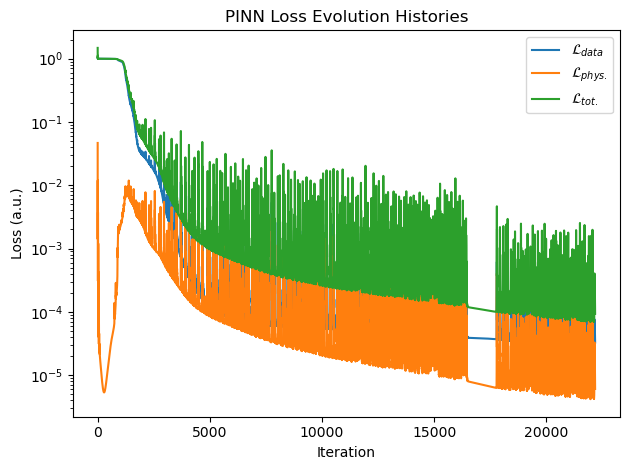

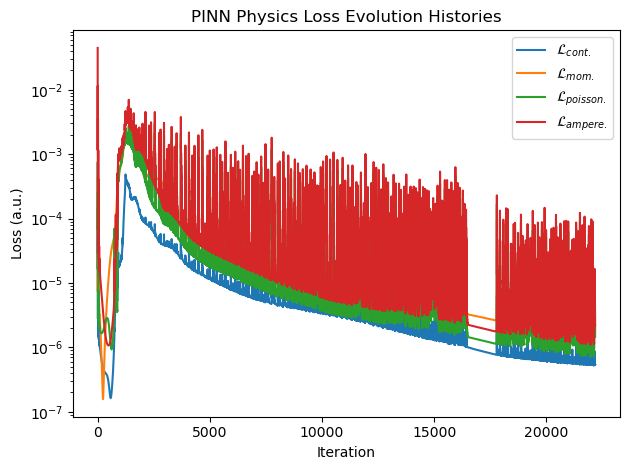

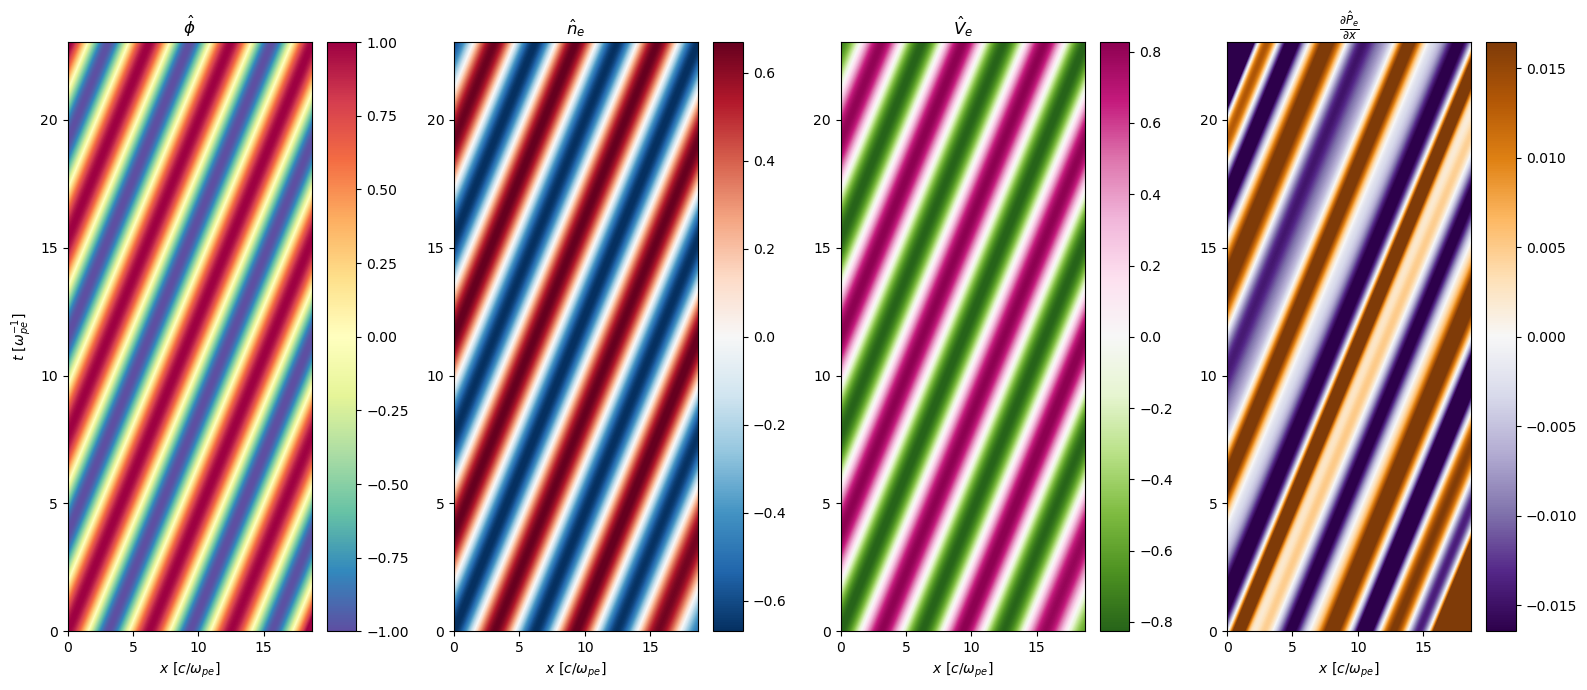

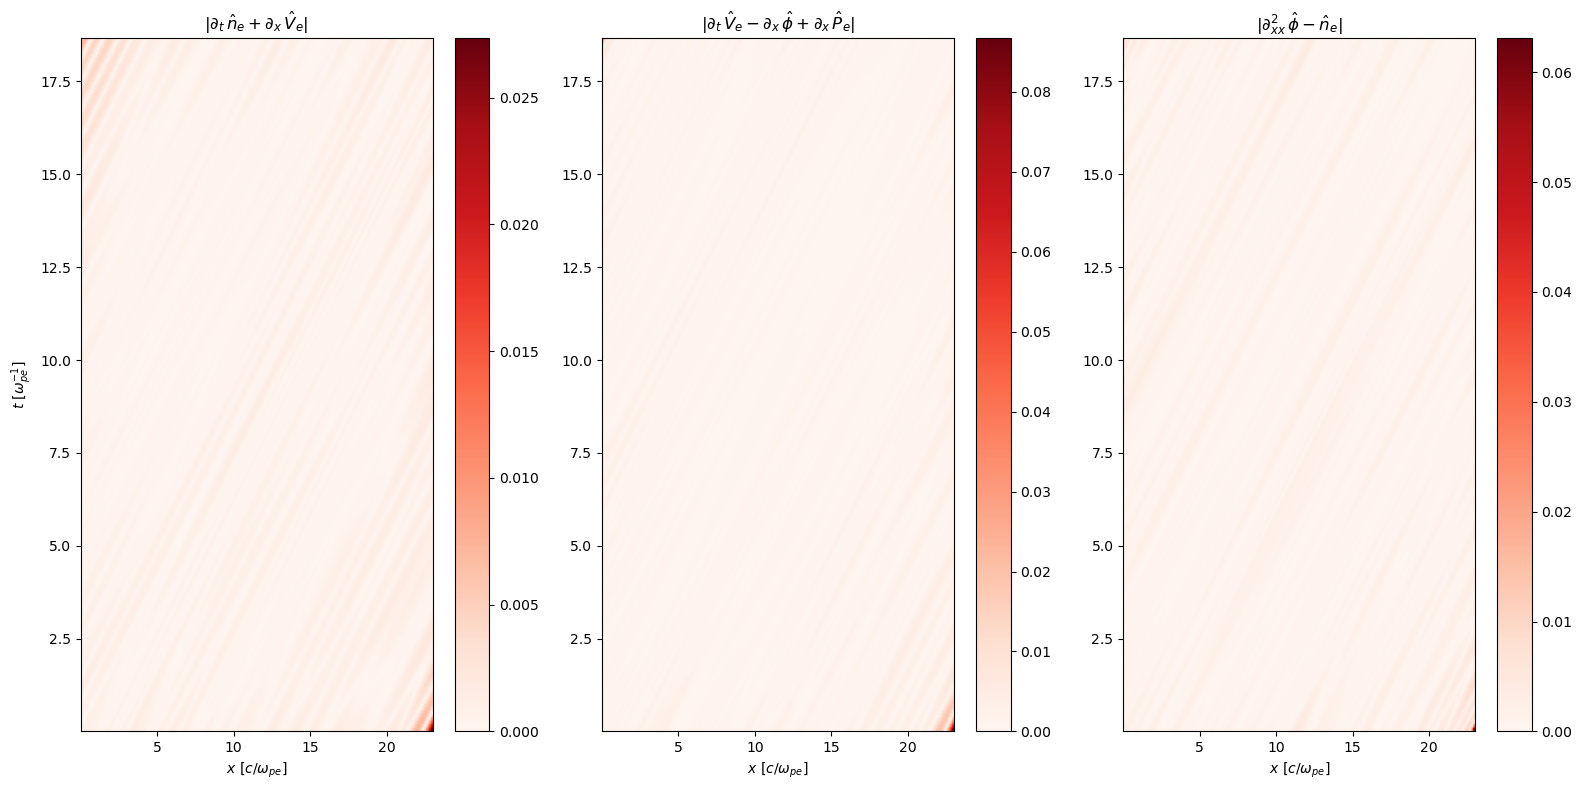

Phi relative error = 0.745 %
N relative error = 2.381 %
V relative error = 2.385 %
P_x relative error = 151.227 %


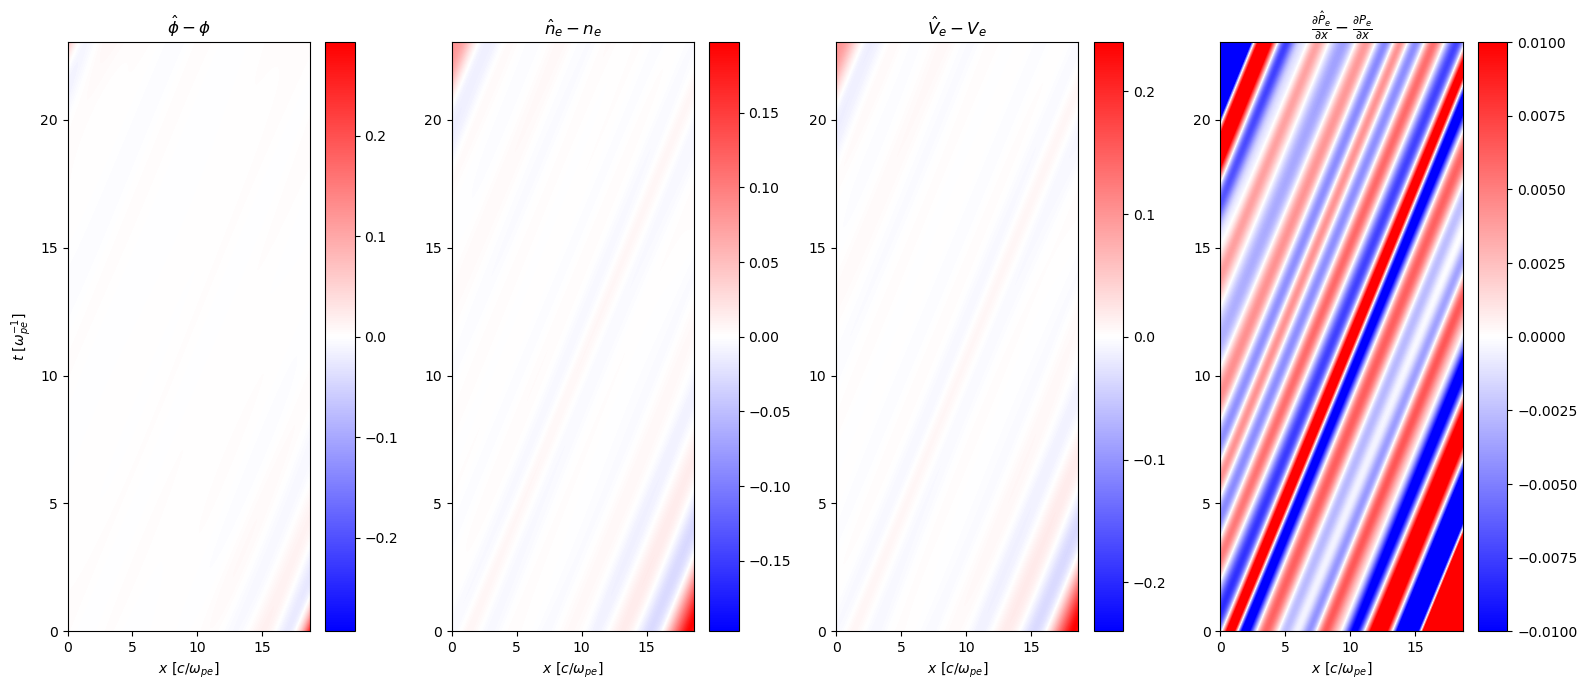

In [ ]:
model.eval()
plot_loss_histories(hist)
plot_reconstructed_quantities(device, model, extent, Nt, Nx, means, stds)
plot_reconstructed_quantity_residuals(device, model, extent, Nt_coll, Nx_coll, means, stds)
plot_reconstructed_quantity_errors(device, model, extent, Nt, Nx, means, stds, phi_GT, N_GT, V_GT, P_x_GT)

In [ ]:
##pickle the model## so we don't have to rerun##
# import pickle 
# with open("langmuir_model_ampere.pkl", 'wb') as f: 
#     pickle.dump(model, f)
# with open("langmuir_model.pkl", 'rb') as f: 
#     stuff = pickle.load(f)
    
# print(type(stuff))

Now let's try to get MSE as a function of sampled size \
We can do one plot for each quantity of interest and one for the average

In [ ]:
def get_mse_errors(device, model, extent, Nt, Nx, means, stds, phi_GT, N_GT, V_GT, P_x_GT):

    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)

    XX, TT = np.meshgrid(X,T)

    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)

    with torch.no_grad():
        phi_pred, N_pred, V_pred, P_x_pred = (model(TT_tensor, XX_tensor)*stds + means).T

    phi_pred = tensor_to_np(phi_pred, reshape=True, dims=(Nt,Nx))
    N_pred = tensor_to_np(N_pred, reshape=True, dims=(Nt,Nx))
    V_pred = tensor_to_np(V_pred, reshape=True, dims=(Nt,Nx))
    P_x_pred = tensor_to_np(P_x_pred, reshape=True, dims=(Nt,Nx))
    
    phi_diff = phi_pred - phi_GT
    N_diff = N_pred - N_GT
    V_diff = V_pred - V_GT
    P_x_diff = P_x_pred - P_x_GT

    rel_err_phi = np.sqrt(np.mean(np.square(phi_diff)) / np.var(phi_GT))
    rel_err_N = np.sqrt(np.mean(np.square(N_diff)) / np.var(N_GT))
    rel_err_V = np.sqrt(np.mean(np.square(V_diff)) / np.var(V_GT))
    rel_err_P_x = np.sqrt(np.mean(np.square(P_x_diff)) / np.var(P_x_GT))
    
    rel_err_average = (rel_err_phi + rel_err_N + rel_err_V + rel_err_P_x)/4
    
    return [rel_err_phi, rel_err_N, rel_err_V, rel_err_P_x, rel_err_average]
    
    #Since we are plotting MSE vs density measurement 

In [ ]:
#Originally have 4000 points and we expect the "elbow" to be at ~5%
num_points_list = [40,200,400,500,1000] #1%, 5%, 10%, 12.5%, 25%
mses = [] #list of list of mse errors 
for pts in num_points_list:
    x_sparse, t_sparse, phi_sparse = sparse_measurements(X_flat, T_flat, phi_flat, num_samples=pts) 
    
    #initializations to train, means and stds vary based on how many we sample
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    extent = [tmin, tmax, xmin, xmax]

    model = torch.jit.script(MLP(extent, device, num_hidden_layers=3, hidden_size=50, activation='tanh', init='xavier').to(device))

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=500)

    t_sparse_tensor = torch.tensor(t_sparse.flatten().reshape(-1,1), dtype=torch.float32, device=device)
    x_sparse_tensor = torch.tensor(x_sparse.flatten().reshape(-1,1), dtype=torch.float32, device=device)
    phi_sparse_tensor = torch.tensor(phi_sparse.flatten().reshape(-1,1), dtype=torch.float32, device=device)

    t_coll_tensor = torch.tensor(t_coll.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)
    x_coll_tensor = torch.tensor(x_coll.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)

    means = torch.zeros((1,4)).to(device)
    stds = torch.ones((1,4)).to(device)

    means[:,0] = torch.mean(phi_sparse_tensor, dim=0)

    stds[:,0] = torch.std(phi_sparse_tensor, dim=0)
    stds[:,1] = phi_amp*k**2
    stds[:,2] = phi_amp*omega*k
    stds[:,3] = np.abs(phi_amp*k*(1. - omega**2))
    
    
    #Converged fairly quickly, so we don't need to train for that long
    model, optimizer, hist = optimize(model, optimizer, scheduler, hist, 1000, 50, \
                                  t_sparse_tensor, x_sparse_tensor, phi_sparse_tensor, \
                                  t_coll_tensor, x_coll_tensor, dt_coll, dx_coll, means, stds, 10.0)
    
    mse_errors = get_mse_errors(device, model, extent, Nt, Nx, means, stds, phi_GT, N_GT, V_GT, P_x_GT)
    mses.append(mse_errors)
print(len(mses))
    

Initializing NN with glorot initialization...



MLP tmin: 0.0000, MLP tmax: 18.6629, MLP xmin: 0.0000, MLP xmax: 23.0284

Number of hidden layers: 3
Hidden layer size: 50 nodes / layer
Input size: 2
Output size: 4

Activation function used: Tanh()
NN parameter initialization mode used: xavier
Use Fourier feature input encoding? False


Network architecture: Sequential(
  (input_linear): Linear(in_features=2, out_features=50, bias=True)
  (input_activation): Tanh()
  (hidden_layer_1): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_1): Tanh()
  (hidden_layer_2): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_2): Tanh()
  (hidden_layer_3): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_3): Tanh()
  (output_linear): Linear(in_features=50, out_features=4, bias=True)
)




Epoch 50 / 200, total loss = 1.2354e-02
Epoch 100 / 200, total loss = 4.1109e-03
Epoch 150 / 200, total loss = 2.2585e-03
Epoch 200 / 200, total loss = 1.4879e-03
Initializing NN with glorot initialization...



MLP tmin: 0.0000, MLP tmax: 18.6629, MLP xmin: 0.0000, MLP xmax: 23.0284

Number of hidden layers: 3
Hidden layer size: 50 nodes / layer
Input size: 2
Output size: 4

Activation function used: Tanh()
NN parameter initialization mode used: xavier
Use Fourier feature input encoding? False


Network architecture: Sequential(
  (input_linear): Linear(in_features=2, out_features=50, bias=True)
  (input_activation): Tanh()
  (hidden_layer_1): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_1): Tanh()
  (hidden_layer_2): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_2): Tanh()
  (hidden_layer_3): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_3): Tanh()
  (output_linear): Linear(in_features=50, out_features=4, 

Pickling the mses from the models, so we won't have to retrain

In [ ]:
# with open("mses.pkl", 'wb') as f:
#     pickle.dump(mses, f)
# with open('mses.pkl', 'rb') as f: 
#     mses = pickle.load(f)
# print(type(mses))

<class 'list'>


In [ ]:
print(mses[4])

[0.015313500043788134, 0.03555990197943917, 0.0357944777353914, 2.035568814812463, 0.5305591736427704]


/tmp/ipykernel_130948/2855021496.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


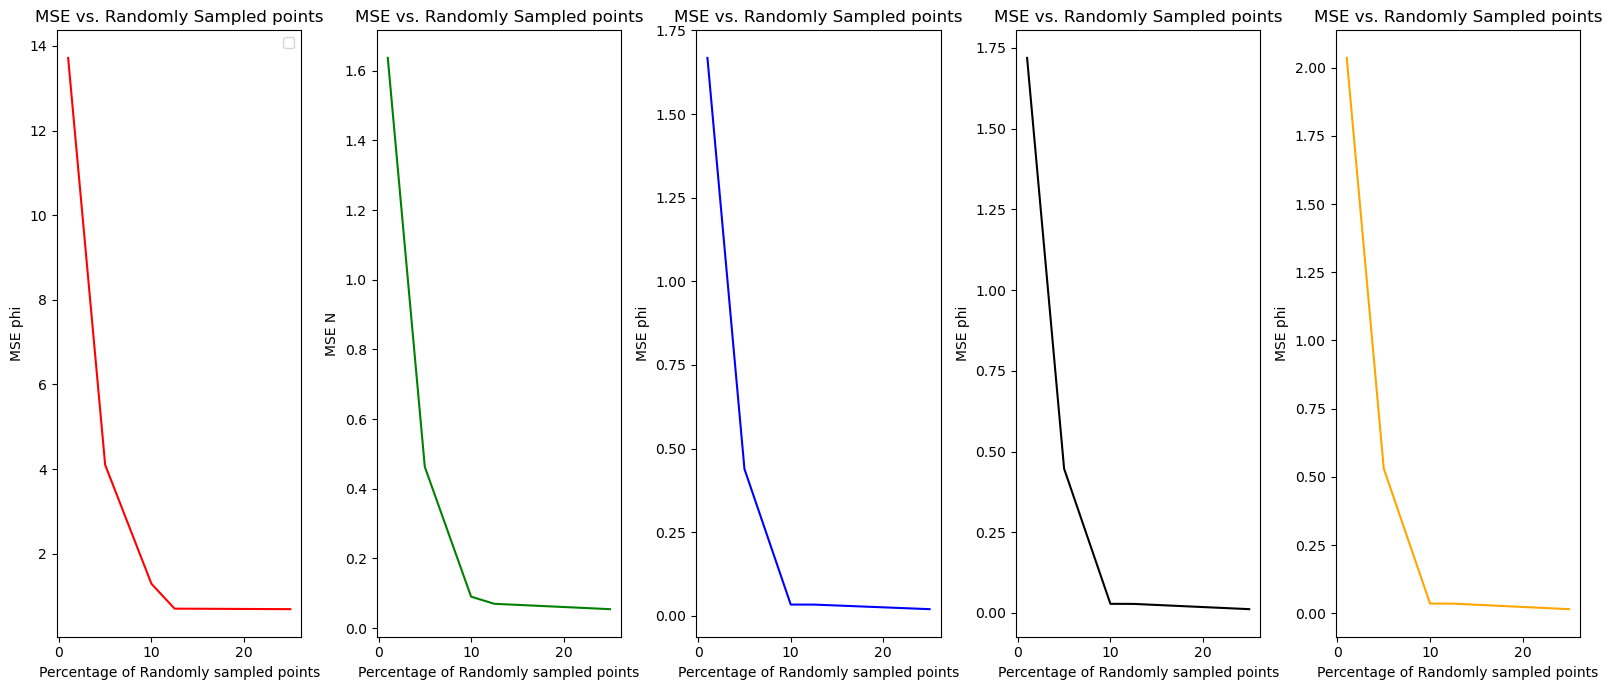

In [ ]:
plt.figure(figsize=(16,7))

plt.subplot(1, 5, 1)
plt.title(r'MSE vs. Randomly Sampled points')
plt.xlabel("Percentage of Randomly sampled points")
plt.ylabel("MSE phi")
plt.plot((np.array(num_points_list)/4000)*100, sorted(mses[0], reverse=True), color = 'r')
plt.legend()

plt.subplot(1, 5, 2)
plt.title(r'MSE vs. Randomly Sampled points')
plt.xlabel("Percentage of Randomly sampled points")
plt.ylabel("MSE N")
plt.plot((np.array(num_points_list)/4000)*100, sorted(mses[1], reverse=True), color = 'g')

plt.subplot(1, 5, 3)
plt.title(r'MSE vs. Randomly Sampled points')
plt.xlabel("Percentage of Randomly sampled points")
plt.ylabel("MSE phi")
plt.plot((np.array(num_points_list)/4000)*100, sorted(mses[2], reverse=True), color = 'blue')

plt.subplot(1, 5, 4)
plt.title(r'MSE vs. Randomly Sampled points')
plt.xlabel("Percentage of Randomly sampled points")
plt.ylabel("MSE phi")
plt.plot((np.array(num_points_list)/4000)*100, sorted(mses[3], reverse=True), color = 'black')

plt.subplot(1, 5, 5)
plt.title(r'MSE vs. Randomly Sampled points')
plt.xlabel("Percentage of Randomly sampled points")
plt.ylabel("MSE phi")
plt.plot((np.array(num_points_list)/4000)*100, sorted(mses[4], reverse=True), color = 'orange')

plt.tight_layout()
    # plt.savefig('reconstructed_quantities_diffs.png', bbox_inches='tight')
plt.show()